In [11]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)
n_samples = 100
x = torch.randn(n_samples, 1) * 2
noise = torch.randn(n_samples, 1) * 0.5
y_true = 2 * x**2 - 3 *x + 1 + noise

X.shape: torch.Size([100, 2])
w1 (x的系数): -2.9944  (真实值: -3)
w2 (x²的系数): 1.9972  (真实值: 2)
b (偏置): 0.9639  (真实值: 1)


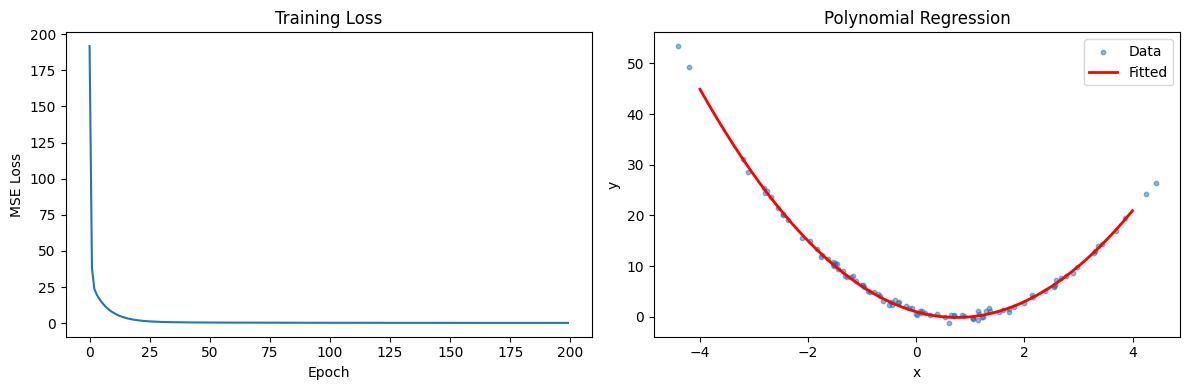

In [12]:
X = torch.cat([x, x ** 2], dim = 1)
print(f"X.shape: {X.shape}")

model = nn.Linear(2, 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)
losses = []

for epoch in range(200):
    y_pred = model(X)
    loss = loss_fn(y_pred, y_true)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

w = model.weight.data
b = model.bias.data
print(f"w1 (x的系数): {w[0][0]:.4f}  (真实值: -3)")
# print(f"w1 (x's coefficient): {w[0][0].4f} (true value -3)")
print(f"w2 (x²的系数): {w[0][1]:.4f}  (真实值: 2)")
# print(f"w2 (x**2's coefficient): {w[0][1].4f} (true value 2)")
# print(f"b (bias value): {b[0].4f} (true value 1)")
print(f"b (偏置): {b[0]:.4f}  (真实值: 1)")

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training Loss")

x_line = torch.linspace(-4, 4, 200).unsqueeze(1)
X_line = torch.cat([x_line, x_line**2], dim=1)
with torch.no_grad():
    y_line = model(X_line)

ax2.scatter(x.numpy(), y_true.numpy(), s=10, alpha=0.5, label="Data")
ax2.plot(x_line.numpy(), y_line.numpy(), 'r-', linewidth=2, label="Fitted")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Polynomial Regression")
ax2.legend()

plt.tight_layout()
plt.show()
                  

In [20]:
class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

torch.manual_seed(42)
n_samples = 100
X = torch.randn(n_samples, 1) * 2
noise = torch.randn(n_samples, 1) * 0.5
y_true = 3 * X + 7 + noise

model = LinearRegression(input_dim = 1, output_dim = 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)
losses = []

for epoch in range(300):
    y_pred = model(X)
    loss = loss_fn(y_pred, y_true)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss)

                   
print(f"weight: {model.linear.weight.item():.4f} (真实值: 3)")
print(f"bias: {model.linear.bias.item():.4f} (真实值: 7)")
    

weight: 3.0036 (真实值: 3)
bias: 7.0033 (真实值: 7)


In [25]:
torch.manual_seed(42)
n_samples = 100
X = torch.randn(n_samples, 1) * 2
noise = torch.randn(n_samples, 1) * 0.5
y_true = 3 * X + 7 + noise

learning_rates = [0.001, 0.01, 0.1, 1]
all_losses = {}

for lr in learning_rates:
    torch.manual_seed(42)
    model = nn.Linear(1, 1)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr)

    losses = []

    for epoch in range(100):
        y_pred = model(X)
        loss = loss_fn(y_pred, y_true)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss)

    all_losses[lr] = losses
    print(f"lr = {lr}, final loss = {losses[-1]:.4f}")





lr = 0.001, final loss = 30.2317
lr = 0.01, final loss = 0.8845
lr = 0.1, final loss = 0.1951
lr = 1, final loss = nan


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

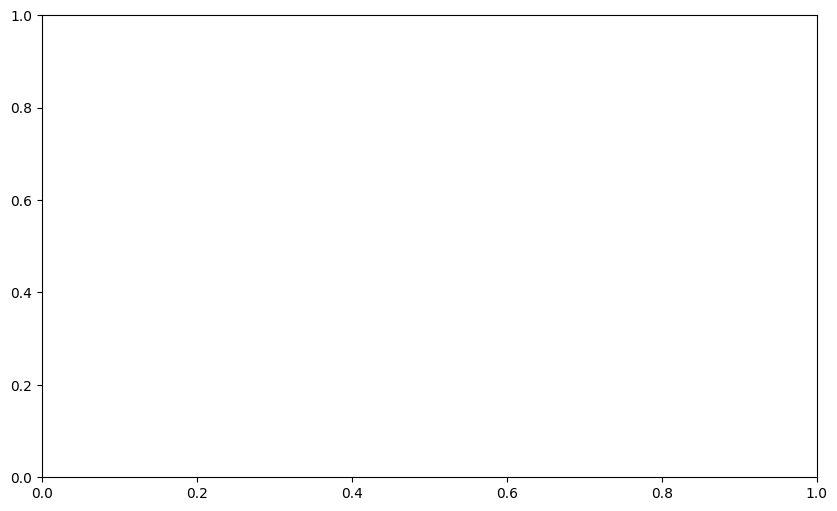

In [26]:
plt.figure(figsize=(10, 6))
for lr, losses in all_losses.items():
    plt.plot(losses, label = f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.yscale("log")
plt.show()